In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import torch
import torch.nn as nn

**Аналитическое дифференцирование**

Числовой пример

In [4]:
x = np.linspace(0, 10, 100)

w_true = 2
b_true = 3

y_clean = w_true * x + b_true

rng = np.random.default_rng(0)
y = y_clean + rng.normal(0, 1, x.shape)

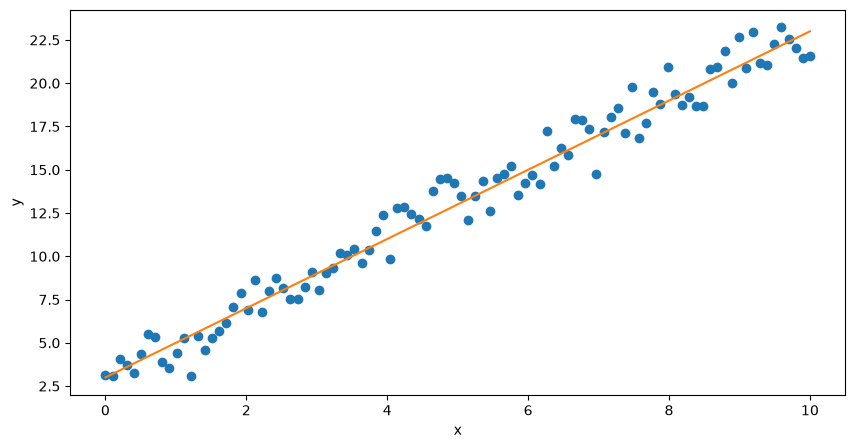

In [5]:
plt.figure(figsize=(10, 5))
plt.plot(x, y, "o")
plt.plot(x, y_clean, "-")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

In [6]:
w = 1
b = 1

y_pred = w * x + b

loss = np.mean((y - y_pred) ** 2)

# Differentiation
dL_dc = 2 * (y - y_pred)

dL_dw = np.mean(dL_dc * -x)
dL_db = np.mean(dL_dc * -1)

print(f'Градиенты: w - {dL_dw}, b - {dL_db}')

Градиенты: w - -88.06187917577817, b - -14.16219338698143


Матричный пример

In [7]:
w_true = np.array([2, 3])
b_true = 2

x = x.reshape(-1, 2)
y_clean = x @ w_true + b_true

In [8]:
w = np.ones(2)
b  = 1

y_pred = x @ w + b

loss = np.mean((y_clean - y_pred) ** 2)

# Differentiation
dL_dc = 2 * (y_clean - y_pred)

dL_dw = -x.T @ dL_dc / len(y_clean)
dL_db = np.mean(dL_dc * -1)

print(f'Градиенты: w - {dL_dw}, b - {dL_db}')

Градиенты: w - [-209.87858382 -213.12111009], b - -32.101010101010104


**Граф вычислений**

Матричный пример

In [20]:
w_true = np.array([9, 3])
b_true = -6

x = x.reshape(-1, 2)

y_clean = x @ w_true + b_true

In [21]:
w = np.ones(2)
b  = 1

c = x @ w
y_pred = c + b

k = y_clean - y_pred
n = k ** 2

loss = np.mean(n)

# Differentiation

dloss = 1
dL_dn = np.full(len(y_clean), 1/len(y_clean))
dL_dk = dL_dn * 2 * k

dL_y_pred = -dL_dk

dL_dc = dL_y_pred
dL_db = np.sum(dL_dc)

dL_dw = x.T @ dL_dc

print(f'Градиенты: w - {dL_dw}, b - {dL_db}')

Градиенты: w - [-592.63952658 -601.26517702], b - -85.39393939393939
